In [5]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from src.config import CONFIG, PROJECT_ROOT

plt.rcParams.update({"figure.figsize": (14, 6), "figure.dpi": 150,
                      "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})

COLORS = {"btc": "#F7931A", "eth": "#627EEA", "vol": "#e74c3c", "calm": "#2ecc71"}
FIGURES = PROJECT_ROOT / "figures"
FIGURES.mkdir(exist_ok=True)

df = pd.read_csv(PROJECT_ROOT / "data/processed/master_enriched.csv",
                 index_col=0, parse_dates=True)
crash_periods = CONFIG["crash_periods"]

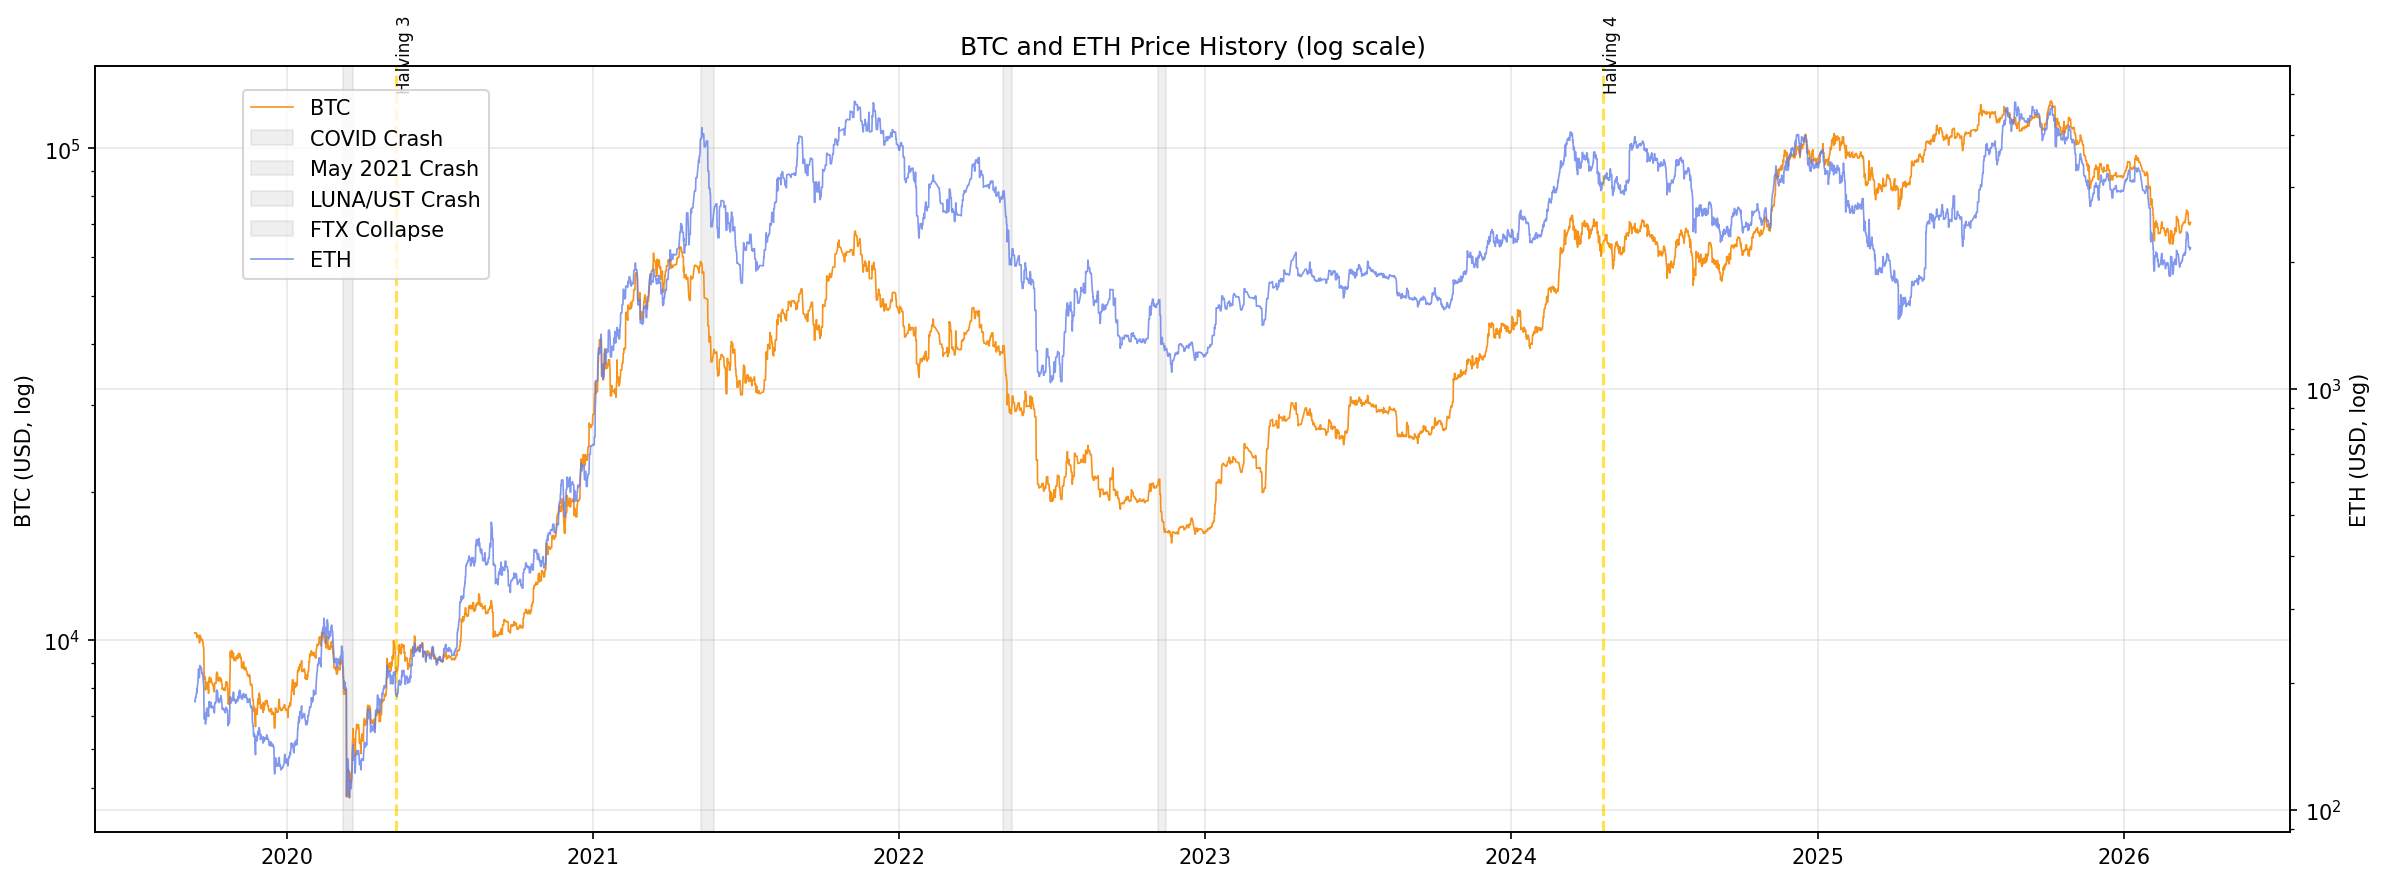

In [6]:
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.semilogy(df.index, df["btc_close"], color=COLORS["btc"], label="BTC", linewidth=0.8)
ax2 = ax1.twinx()
ax2.semilogy(df.index, df["eth_close"], color=COLORS["eth"], label="ETH", linewidth=0.8, alpha=0.8)

# Crash overlays
for cp in crash_periods:
    ax1.axvspan(pd.Timestamp(cp["start"]), pd.Timestamp(cp["end"]),
                alpha=0.15, color="#999", label=cp["name"])

# Halving annotations
for date, label in [("2020-05-11", "Halving 3"), ("2024-04-20", "Halving 4")]:
    ax1.axvline(pd.Timestamp(date), color="gold", linestyle="--", alpha=0.7)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1]*0.9, label, fontsize=8, rotation=90)

ax1.set_ylabel("BTC (USD, log)")
ax2.set_ylabel("ETH (USD, log)")
ax1.set_title("BTC and ETH Price History (log scale)")
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
fig.tight_layout()
fig.savefig(FIGURES / "price_history.png", bbox_inches="tight")
plt.show()

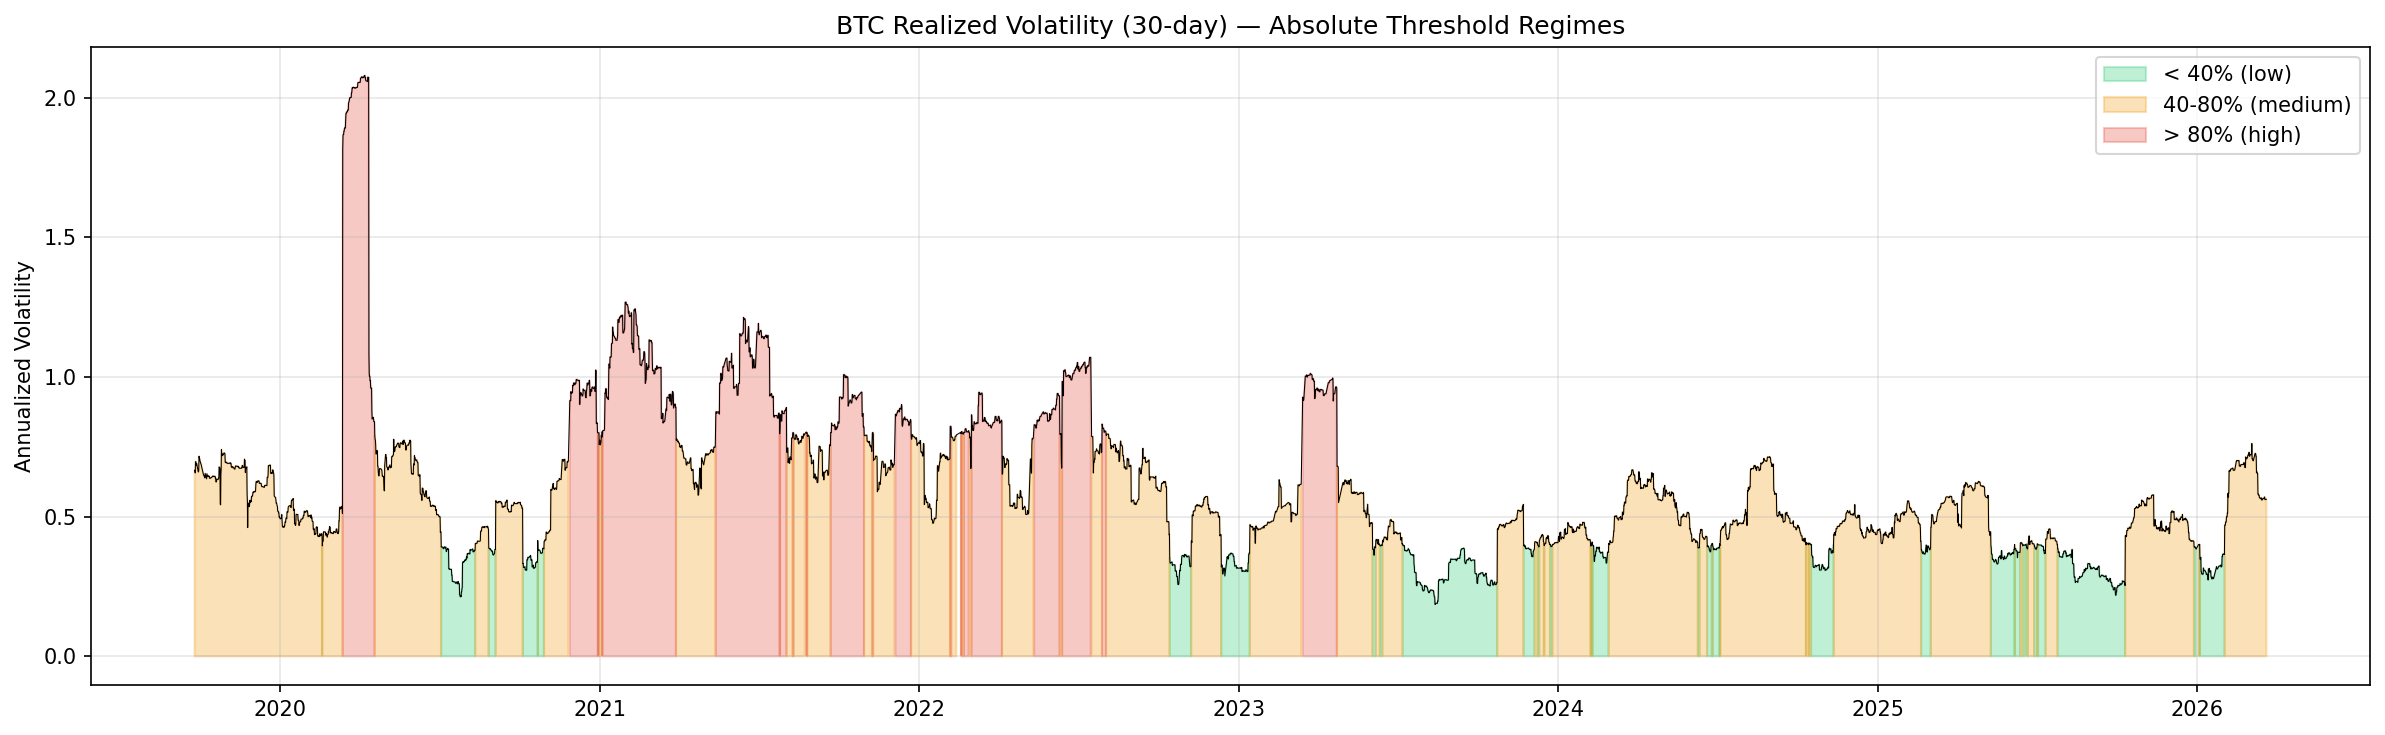

In [7]:
fig, ax = plt.subplots(figsize=(16, 5))
vol = df["btc_realized_vol_90p"]
ax.plot(df.index, vol, color="black", linewidth=0.5)

# ABSOLUTE thresholds (not full-sample quantiles = no look-ahead)
ax.fill_between(df.index, 0, vol, where=vol < 0.4, alpha=0.3, color=COLORS["calm"], label="< 40% (low)")
ax.fill_between(df.index, 0, vol, where=(vol >= 0.4) & (vol < 0.8), alpha=0.3, color="#f39c12", label="40-80% (medium)")
ax.fill_between(df.index, 0, vol, where=vol >= 0.8, alpha=0.3, color=COLORS["vol"], label="> 80% (high)")

ax.set_ylabel("Annualized Volatility")
ax.set_title("BTC Realized Volatility (30-day) — Absolute Threshold Regimes")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "volatility_regimes.png", bbox_inches="tight")
plt.show()